In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import StratifiedKFold
import joblib

warnings.filterwarnings('ignore')

def locate_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data').exists():
            return candidate
    return current

root = locate_root()
data_dir = root / 'data'
metadata_dir = data_dir / 'metadata'
processed_dir = data_dir / 'processed'
models_dir = root / 'models'
reports_dir = root / 'reports'
figures_dir = reports_dir / 'figures'
tables_dir = reports_dir / 'tables'

for d in [models_dir, figures_dir, tables_dir]:
    d.mkdir(parents=True, exist_ok=True)

print('Root:', root)

/home/hamza/Documents/aero-res/aircraft_fault_localization/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Root: /home/hamza/Documents/aero-res/aircraft_fault_localization


In [2]:
standardized_df = pd.read_parquet(processed_dir / 'flight_rows_standardized.parquet')
scores_df = pd.read_parquet(processed_dir / 'anomaly_model_scores.parquet')
feature_manifest = pd.read_csv(metadata_dir / 'feature_manifest.csv')
models = joblib.load(models_dir / 'anomaly_models.pkl')

available_features = models['features']
scaler = models['scaler']
pca_pre = models['pca_pre']

healthy_count = (standardized_df['group'] == 'healthy').sum()
defective_count = (standardized_df['group'] == 'defective').sum()
imbalance_ratio = defective_count / healthy_count

print(f'Healthy rows    : {healthy_count:,}')
print(f'Defective rows  : {defective_count:,}')
print(f'Imbalance ratio : {imbalance_ratio:.3f}  ({defective_count}/{healthy_count})')

Healthy rows    : 142,391
Defective rows  : 170,110
Imbalance ratio : 1.195  (170110/142391)


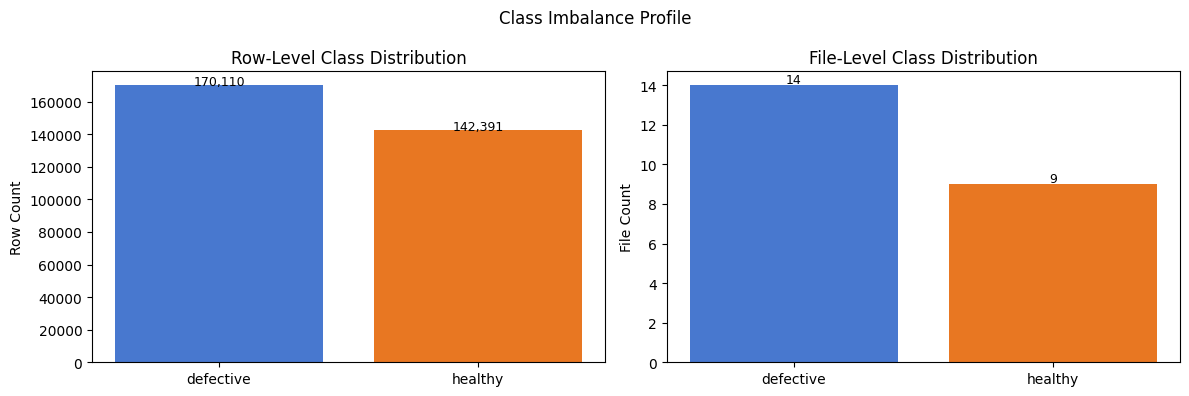

Row imbalance ratio (defective/healthy): 1.195
File imbalance ratio: 14/9


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

group_counts = standardized_df['group'].value_counts()
axes[0].bar(group_counts.index, group_counts.values, color=['#4878CF', '#E87722'])
axes[0].set_title('Row-Level Class Distribution')
axes[0].set_ylabel('Row Count')
for bar, val in zip(axes[0].patches, group_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200, f'{val:,}', ha='center', fontsize=9)

file_counts = standardized_df.groupby('group')['file_name'].nunique()
axes[1].bar(file_counts.index, file_counts.values, color=['#4878CF', '#E87722'])
axes[1].set_title('File-Level Class Distribution')
axes[1].set_ylabel('File Count')
for bar, val in zip(axes[1].patches, file_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, str(val), ha='center', fontsize=9)

plt.suptitle('Class Imbalance Profile', fontsize=12)
plt.tight_layout()
plt.savefig(figures_dir / 'class_imbalance_profile.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Row imbalance ratio (defective/healthy): {imbalance_ratio:.3f}')
print(f'File imbalance ratio: {file_counts.get("defective", 0)}/{file_counts.get("healthy", 0)}')

In [4]:
y_true = (standardized_df['group'] == 'defective').astype(int).values

score_cols = {
    'iso_score': True,
    'ocsvm_score': True,
    'spe': False,
    't2': False,
}

pr_data = {}
for col, invert in score_cols.items():
    raw = scores_df[col].values
    score = -raw if invert else raw
    ap = average_precision_score(y_true, score)
    auc = roc_auc_score(y_true, score)
    precision, recall, thresholds = precision_recall_curve(y_true, score)
    pr_data[col] = {'precision': precision, 'recall': recall, 'ap': ap, 'auc': auc}
    print(f'{col:20s}  AP={ap:.4f}  ROC-AUC={auc:.4f}')

iso_score             AP=0.8106  ROC-AUC=0.8110
ocsvm_score           AP=0.7581  ROC-AUC=0.6471
spe                   AP=0.9775  ROC-AUC=0.9801
t2                    AP=0.8316  ROC-AUC=0.8159


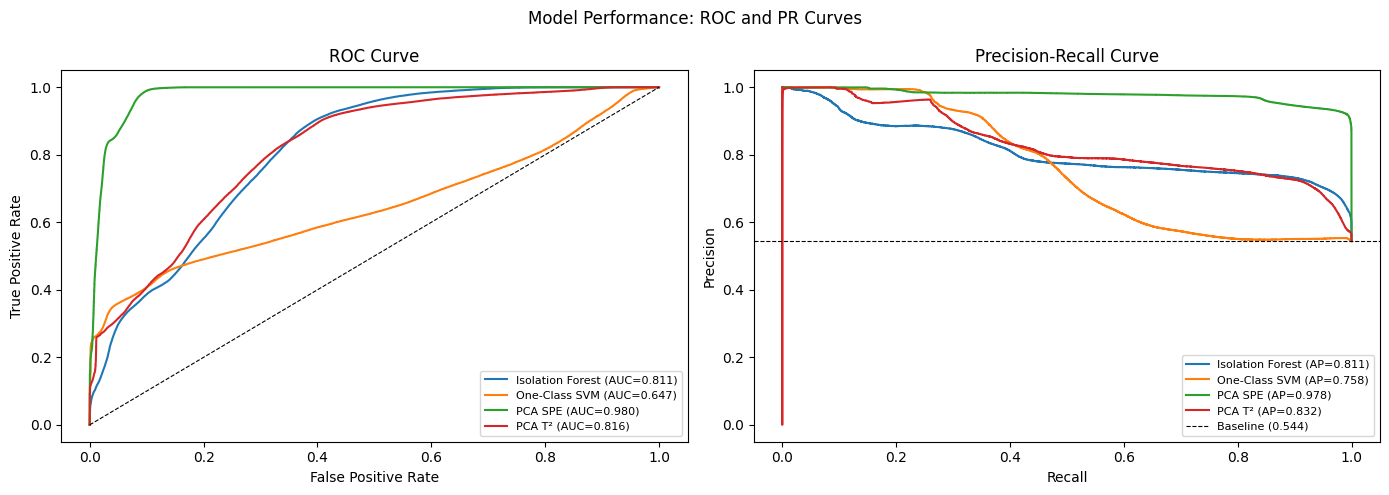

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels = {
    'iso_score': 'Isolation Forest',
    'ocsvm_score': 'One-Class SVM',
    'spe': 'PCA SPE',
    't2': 'PCA T²'
}

from sklearn.metrics import roc_curve

for (col, invert), color in zip(score_cols.items(), colors):
    raw = scores_df[col].values
    score = -raw if invert else raw
    fpr, tpr, _ = roc_curve(y_true, score)
    axes[0].plot(fpr, tpr, color=color, label=f"{labels[col]} (AUC={pr_data[col]['auc']:.3f})")
    axes[1].plot(pr_data[col]['recall'], pr_data[col]['precision'], color=color,
                 label=f"{labels[col]} (AP={pr_data[col]['ap']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

baseline = y_true.mean()
axes[1].axhline(baseline, color='k', linestyle='--', linewidth=0.8, label=f'Baseline ({baseline:.3f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)

plt.suptitle('Model Performance: ROC and PR Curves', fontsize=12)
plt.tight_layout()
plt.savefig(figures_dir / 'model_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
def find_optimal_threshold(y_true, score, beta=1.0):
    precision, recall, thresholds = precision_recall_curve(y_true, score)
    f_scores = np.where(
        (precision + recall) > 0,
        (1 + beta**2) * precision * recall / (beta**2 * precision + recall),
        0.0
    )
    best_idx = np.argmax(f_scores[:-1])
    return thresholds[best_idx], f_scores[best_idx], precision[best_idx], recall[best_idx]

threshold_results = []
for col, invert in score_cols.items():
    raw = scores_df[col].values
    score = -raw if invert else raw
    best_thr, best_f1, best_prec, best_rec = find_optimal_threshold(y_true, score, beta=1.0)
    threshold_results.append({
        'model': labels[col],
        'score_col': col,
        'optimal_threshold': best_thr,
        'f1': best_f1,
        'precision': best_prec,
        'recall': best_rec,
        'roc_auc': pr_data[col]['auc'],
        'avg_precision': pr_data[col]['ap']
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.to_csv(tables_dir / 'model_threshold_comparison.csv', index=False)
print(threshold_df.to_string(index=False))

           model   score_col  optimal_threshold       f1  precision   recall  roc_auc  avg_precision
Isolation Forest   iso_score          -0.114850 0.810606   0.721199 0.925319 0.810956       0.810607
   One-Class SVM ocsvm_score         -10.628829 0.709764   0.552802 0.991206 0.647054       0.758073
         PCA SPE         spe          15.422259 0.954674   0.922450 0.989230 0.980086       0.977530
          PCA T²          t2          26.938917 0.805517   0.719030 0.915655 0.815915       0.831598


In [7]:
X_all = standardized_df[available_features].fillna(0).astype(np.float32)
X_all_scaled = scaler.transform(X_all)
X_all_pca = pca_pre.transform(X_all_scaled)

healthy_mask = standardized_df['group'] == 'healthy'
defective_mask = standardized_df['group'] == 'defective'

X_h = X_all_pca[healthy_mask.values]
X_d = X_all_pca[defective_mask.values]

n_h = len(X_h)
n_d = len(X_d)

contamination_values = [0.02, 0.05, 0.10, 0.15, 0.20]

X_train_h = X_h[:min(30_000, n_h)]

contamination_metrics = []
for cont in tqdm(contamination_values, desc='Tuning contamination'):
    iso = IsolationForest(n_estimators=150, contamination=cont, random_state=42, n_jobs=-1)
    iso.fit(X_train_h)
    preds = iso.predict(X_all_pca)
    y_pred = (preds == -1).astype(int)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    contamination_metrics.append({'contamination': cont, 'f1': f1, 'precision': prec, 'recall': rec})

cont_df = pd.DataFrame(contamination_metrics)
print(cont_df.to_string(index=False))

best_cont = cont_df.loc[cont_df['f1'].idxmax(), 'contamination']
print(f'\nBest contamination: {best_cont}')

Tuning contamination: 100%|██████████| 5/5 [00:15<00:00,  3.12s/it]

 contamination       f1  precision   recall
          0.02 0.328811   0.880260 0.202163
          0.05 0.512429   0.841998 0.368279
          0.10 0.620484   0.779510 0.515349
          0.15 0.720007   0.749976 0.692340
          0.20 0.784936   0.724793 0.855964

Best contamination: 0.2


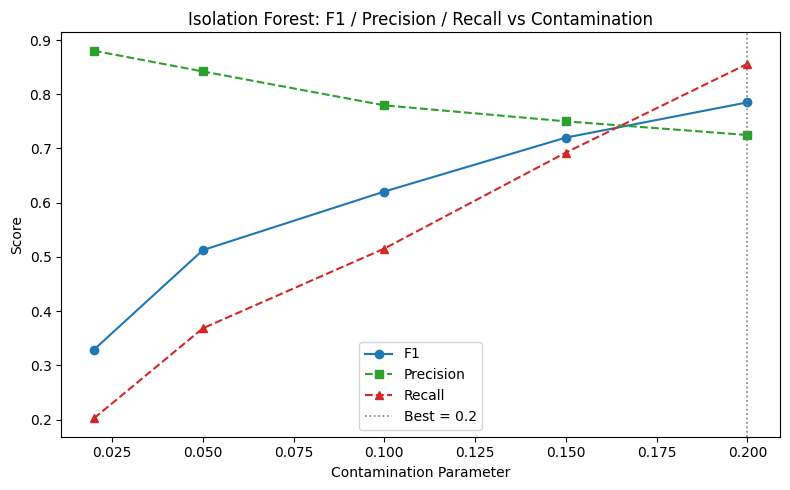

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cont_df['contamination'], cont_df['f1'], 'o-', label='F1', color='#1f77b4')
ax.plot(cont_df['contamination'], cont_df['precision'], 's--', label='Precision', color='#2ca02c')
ax.plot(cont_df['contamination'], cont_df['recall'], '^--', label='Recall', color='#d62728')
ax.axvline(best_cont, color='gray', linestyle=':', linewidth=1.2, label=f'Best = {best_cont}')
ax.set_xlabel('Contamination Parameter')
ax.set_ylabel('Score')
ax.set_title('Isolation Forest: F1 / Precision / Recall vs Contamination')
ax.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'contamination_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('Training refined Isolation Forest ...')
iso_refined = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=float(best_cont),
    random_state=42,
    n_jobs=-1
)
iso_refined.fit(X_train_h)

refined_scores = iso_refined.decision_function(X_all_pca)
refined_preds = iso_refined.predict(X_all_pca)

scores_df['iso_refined_score'] = refined_scores
scores_df['iso_refined_anomaly'] = (refined_preds == -1).astype(int)

refined_f1 = f1_score(y_true, (refined_preds == -1).astype(int), zero_division=0)
refined_auc = roc_auc_score(y_true, -refined_scores)
print(f'Refined Isolation Forest  F1={refined_f1:.4f}  ROC-AUC={refined_auc:.4f}')

Training refined Isolation Forest ...
Refined Isolation Forest  F1=0.7904  ROC-AUC=0.8070


In [10]:
spe_col = scores_df['spe'].values
t2_col = scores_df['t2'].values
iso_col = -refined_scores

def minmax_norm(x):
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    return np.clip((x - lo) / (hi - lo + 1e-10), 0, 1)

spe_norm = minmax_norm(spe_col)
t2_norm = minmax_norm(t2_col)
iso_norm = minmax_norm(iso_col)
ocsvm_norm = minmax_norm(-scores_df['ocsvm_score'].values)

ensemble_score = (spe_norm + t2_norm + iso_norm + ocsvm_norm) / 4
scores_df['ensemble_score_norm'] = ensemble_score

best_ens_thr, best_ens_f1, best_ens_prec, best_ens_rec = find_optimal_threshold(y_true, ensemble_score)
scores_df['ensemble_refined_anomaly'] = (ensemble_score >= best_ens_thr).astype(int)

ens_auc = roc_auc_score(y_true, ensemble_score)
print(f'Refined Ensemble  F1={best_ens_f1:.4f}  ROC-AUC={ens_auc:.4f}  threshold={best_ens_thr:.4f}')

Refined Ensemble  F1=0.7792  ROC-AUC=0.8136  threshold=0.0921


In [11]:
scores_df.to_parquet(processed_dir / 'anomaly_model_scores.parquet', index=False)

file_refined_summary = scores_df.groupby('file_name').agg(
    group=('group', 'first'),
    total_rows=('sequence_index', 'count'),
    iso_refined_anomaly_rate=('iso_refined_anomaly', 'mean'),
    ensemble_refined_anomaly_rate=('ensemble_refined_anomaly', 'mean'),
    mean_ensemble_score=('ensemble_score_norm', 'mean'),
).reset_index().sort_values('mean_ensemble_score', ascending=False)

file_refined_summary.to_csv(tables_dir / 'refined_model_file_summary.csv', index=False)

cont_df.to_csv(tables_dir / 'contamination_tuning.csv', index=False)

models['iso_refined'] = iso_refined
models['ensemble_threshold'] = best_ens_thr
models['best_contamination'] = float(best_cont)
joblib.dump(models, models_dir / 'anomaly_models.pkl')

print('Refined models and summaries saved.')
print(file_refined_summary.head(10).to_string(index=False))

Refined models and summaries saved.
        file_name     group  total_rows  iso_refined_anomaly_rate  ensemble_refined_anomaly_rate  mean_ensemble_score
  Defected 2.xlsx defective        4902                  1.000000                       1.000000             0.749011
Defect15(02).xlsx defective        4902                  1.000000                       1.000000             0.749011
  Defected 5.xlsx defective        9690                  1.000000                       1.000000             0.424029
Defect16(01).xlsx defective        9690                  1.000000                       1.000000             0.424029
  Defected 1.xlsx defective       12431                  0.959537                       1.000000             0.408529
Defect15(01).xlsx defective       12431                  0.959537                       1.000000             0.408529
  Defected 6.xlsx defective       14537                  1.000000                       0.999931             0.257016
Defect16(02).xlsx de

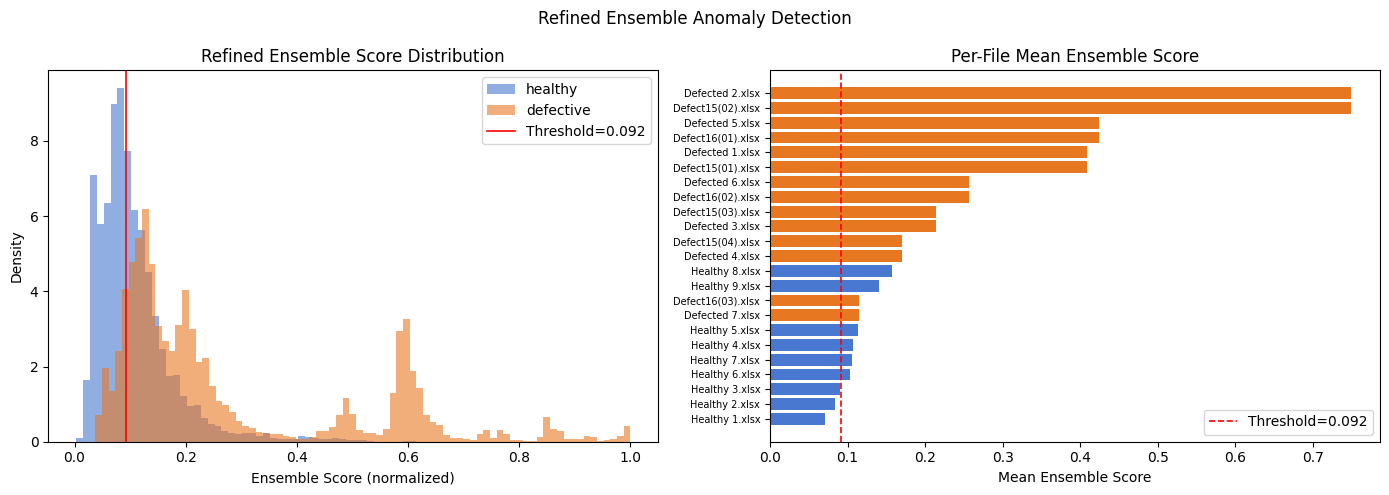

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for group, color in [('healthy', '#4878CF'), ('defective', '#E87722')]:
    mask = scores_df['group'] == group
    axes[0].hist(scores_df.loc[mask, 'ensemble_score_norm'], bins=80, alpha=0.6, color=color, label=group, density=True)
axes[0].axvline(best_ens_thr, color='red', linewidth=1.2, label=f'Threshold={best_ens_thr:.3f}')
axes[0].set_title('Refined Ensemble Score Distribution')
axes[0].set_xlabel('Ensemble Score (normalized)')
axes[0].set_ylabel('Density')
axes[0].legend()

sorted_summary = file_refined_summary.sort_values('mean_ensemble_score', ascending=True)
colors_bar = ['#E87722' if g == 'defective' else '#4878CF' for g in sorted_summary['group']]
axes[1].barh(sorted_summary['file_name'], sorted_summary['mean_ensemble_score'], color=colors_bar)
axes[1].axvline(best_ens_thr, color='red', linewidth=1.2, linestyle='--', label=f'Threshold={best_ens_thr:.3f}')
axes[1].set_title('Per-File Mean Ensemble Score')
axes[1].set_xlabel('Mean Ensemble Score')
axes[1].legend()
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('Refined Ensemble Anomaly Detection', fontsize=12)
plt.tight_layout()
plt.savefig(figures_dir / 'refined_ensemble_summary.png', dpi=150, bbox_inches='tight')
plt.show()